In [14]:
import pandas as pd


In [15]:
# let's create a simple and small data set first to understand k-means clustering
df = pd.DataFrame({
    'Name':['Rob', 'Michel','Mohan','Ismall', 'Kory'],
    'Age' :[27,29,29,28,42],
    'Income':[70000, 90000, 61000, 60000, 150000]
})
df

,Name,Age,Income
0,Rob,27,70000
1,Michel,29,90000
2,Mohan,29,61000
3,Ismall,28,60000
4,Kory,42,150000


In [17]:
df.to_csv('income.csv', index=False)

In [18]:
# i added some more values in the csv file and fetching the file again
df = pd.read_csv('income.csv')
df

,Name,Age,Income
0,Rob,27,70000
1,Michel,29,90000
2,Mohan,29,61000
3,Ismall,28,60000
4,Kory,42,150000
5,Gautam,39,162000
6,David,41,156000
7,Andra,38,130000
8,sanda,36,137000
9,panda,35,45000


In [ ]:
df1 = 

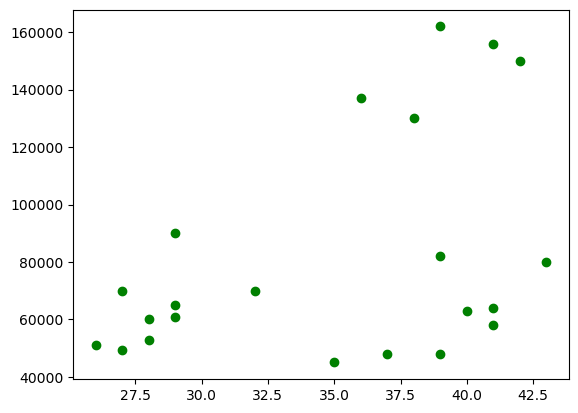

In [19]:
import matplotlib.pyplot as plt
plt.scatter(df['Age'],df['Income'], color ='green')


In [20]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters=3)

In [21]:
km

KMeans(n_clusters=3)

In [24]:
y_pred =km.fit_predict(df[['Age','Income']])

C:\Users\pc\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\pc\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [25]:
y_pred

array([2, 2, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 2, 1, 1])

In [26]:
df['cluster'] =y_pred

In [28]:
df.head()

,Name,Age,Income,cluster
0,Rob,27,70000,2
1,Michel,29,90000,2
2,Mohan,29,61000,1
3,Ismall,28,60000,1
4,Kory,42,150000,0


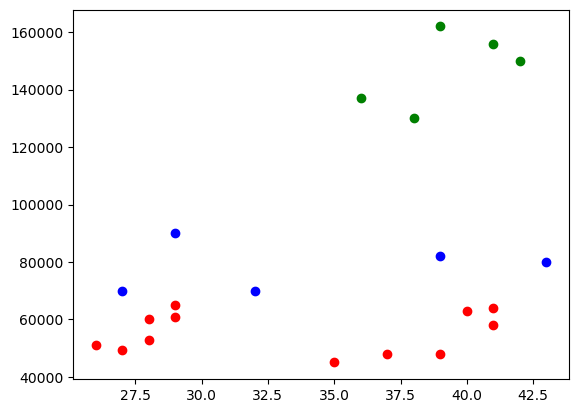

In [32]:
df0 = df[df.cluster==0]
df1 = df[df.cluster==1]
df2 = df[df.cluster==2]
plt.scatter(df0['Age'], df0['Income'], color='green')
plt.scatter(df1['Age'], df1['Income'], color='red')
plt.scatter(df2['Age'], df2['Income'], color='blue')

we can see green is separate cluster but the lower 2 clusters have problem bcs we didn't scale the features

In [34]:
# using mixmax scaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [36]:
scaler.fit(df[['Income']])
df['Income'] =scaler.transform(df[['Income']])
df.head()

,Name,Age,Income,cluster
0,Rob,27,0.213675,2
1,Michel,29,0.384615,2
2,Mohan,29,0.136752,1
3,Ismall,28,0.128205,1
4,Kory,42,0.897436,0


In [41]:
scaler.fit(df[['Age']])
df['Age'] =scaler.transform(df[['Age']])
df.head()

,Name,Age,Income,cluster
0,Rob,0.058824,0.213675,2
1,Michel,0.176471,0.384615,2
2,Mohan,0.176471,0.136752,1
3,Ismall,0.117647,0.128205,1
4,Kory,0.941176,0.897436,0


In [43]:
Km = KMeans(n_clusters=3)
df.cluster =Km.fit_predict(df[['Age','Income']])

C:\Users\pc\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\pc\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


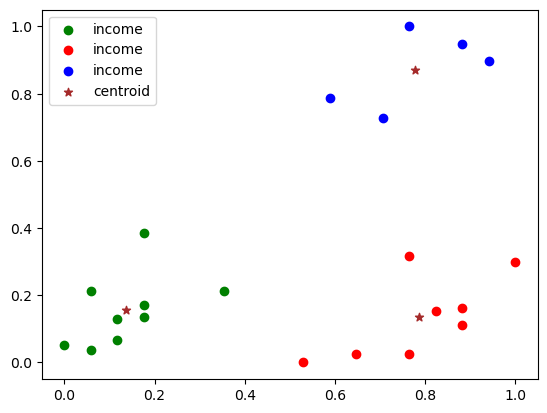

In [48]:
df0 = df[df.cluster==0]
df1 = df[df.cluster==1]
df2 = df[df.cluster==2]

plt.scatter(df0['Age'], df0['Income'], color='green',label='income')
plt.scatter(df1['Age'], df1['Income'], color='red', label='income')
plt.scatter(df2['Age'], df2['Income'], color='blue',label='income')
plt.scatter(Km.cluster_centers_[:,0], Km.cluster_centers_[:,1],color='brown',marker='*', label='centroid')
plt.legend()

In [49]:
k_range =range(1,10)
sse = []
for k in k_range:
    km = KMeans(n_clusters=k)
    km.fit(df[['Age','Income']])
    sse.append(km.inertia_)

C:\Users\pc\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\pc\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\pc\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\pc\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable 

In [50]:
sse

[4.809063810117399,
 2.124466034195281,
 0.5615120544987264,
 0.3991002185108989,
 0.2988968374717446,
 0.2045992057082467,
 0.16794309736373447,
 0.1435116409904214,
 0.11901633569852901]

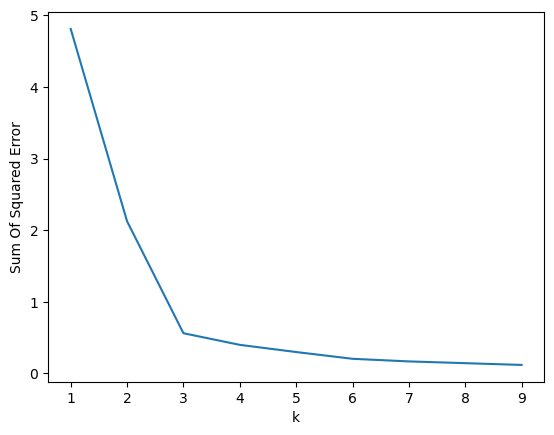

In [52]:
plt.xlabel('k')
plt.ylabel('Sum Of Squared Error')
plt.plot(k_range,sse)